In [ ]:
!pip install kagglehub
!pip install tensorflow

In [54]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anilkrsah/deepmushroom")

print("Path to dataset files:", path)

100%|██████████| 1.33G/1.33G [01:15<00:00, 18.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/anilkrsah/deepmushroom/versions/1


In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from PIL import Image
import numpy as np
import random
from random import shuffle

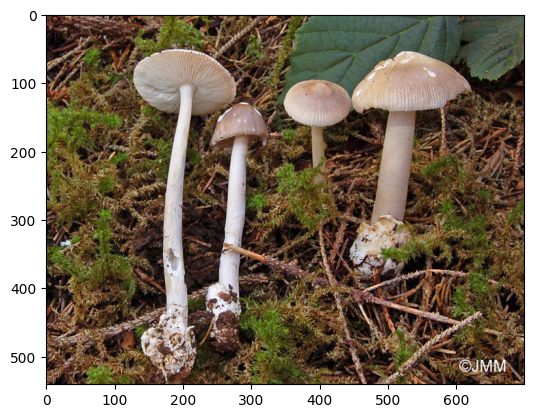

In [56]:
# checkout the dataset to make sure it works
data_path = path + "/Mushrooms/"
test_img = mpimg.imread(data_path + "Amanita/002_pJY3-9Ttfto.jpg")
img = plt.imshow(test_img)
plt.show()

In [115]:
# build the dataset
x = []
y = []

# get labels
labels = []
for species in os.listdir(data_path):
  label = species.lower()
  labels.append(label)

def one_hot_encode(label):
  one_hot_labels = []
  for species in labels:
    if species == label:
      one_hot_labels.append(1)
    else:
      one_hot_labels.append(0)
  return one_hot_labels

# go over all folders in the dataset
for species in os.listdir(data_path):
  label = species.lower()
  for image in os.listdir(data_path + species):
    image_path = data_path + species + "/" + image
    img = Image.open(image_path)
    img = img.resize((64, 64))
    img = img.convert("RGB")
    #img = img.convert("L")
    img_arr = np.array(img)
    x.append(img_arr)
    y.append(one_hot_encode(label))

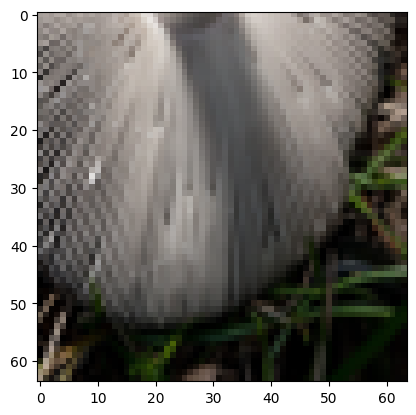

[[[167 160 155]
  [172 163 158]
  [163 154 150]
  ...
  [ 45  42  37]
  [ 31  26  25]
  [ 28  22  21]]

 [[158 151 146]
  [168 160 156]
  [165 157 152]
  ...
  [ 92  84  76]
  [ 39  34  31]
  [ 43  37  33]]

 [[154 145 142]
  [133 124 121]
  [150 142 138]
  ...
  [ 54  47  42]
  [ 30  25  22]
  [ 32  25  22]]

 ...

 [[124 121  73]
  [184 166 148]
  [112  91  73]
  ...
  [  5   5   2]
  [  7   4   3]
  [  9   4   2]]

 [[155 143 115]
  [134 117  90]
  [ 59  44  30]
  ...
  [  5   4   2]
  [  7   4   3]
  [ 11   7   4]]

 [[162 148 131]
  [ 55  50  36]
  [ 21  16  14]
  ...
  [  6   5   2]
  [  6   4   4]
  [  8   5   4]]]


In [116]:
plt.imshow(Image.fromarray(x[2000]))
plt.show()
print(x[2000])

In [117]:
temp = list(zip(x, y))
random.shuffle(temp)
x, y = zip(*temp)
x = list(x)
y = list(y)
print(len(x), len(y))

9533 9533


In [118]:
# training test split

x_train = np.array(x[0:int(0.8 * len(x))])
x_test = np.array(x[int(0.8 * len(x)):])
y_train = np.array(y[0:int(0.8 * len(y))])
y_test = np.array(y[int(0.8 * len(y)):])
print(len(x_train), len(y_train))

7626 7626


In [119]:
# build the model
model = models.Sequential()
model.add(layers.Conv2D(32, (4, 4), activation='relu', input_shape = (64, 64, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (4, 4), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (4, 4), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (4, 4), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [120]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation = 'relu'))
model.add(layers.Dense(12))

In [121]:
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)                   │ (None, 61, 61, 32)          │           1,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_59 (MaxPooling2D)      │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_61 (Conv2D)                   │ (None, 27, 27, 64)          │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_60 (MaxPooling2D)      │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_62 (Conv2D)                   │ (None, 10, 10, 64)          │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_61 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_63 (Conv2D)                   │ (None, 2, 2, 64)            │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_62 (MaxPooling2D)      │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_15 (Flatten)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 12)                  │             780 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 170,540 (666.17 KB)

 Trainable params: 170,540 (666.17 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
model.compile(optimizer = 'adamw',
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics = ['accuracy'])
result = model.fit(x_train, y_train, epochs = 20, validation_data=(x_test, y_test))

Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1297 - loss: 4.2656 - val_accuracy: 0.1935 - val_loss: 2.3009
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2043 - loss: 2.3037 - val_accuracy: 0.2480 - val_loss: 2.2090
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2549 - loss: 2.2115 - val_accuracy: 0.2496 - val_loss: 2.1844
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2719 - loss: 2.1258 - val_accuracy: 0.2973 - val_loss: 2.0869
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3130 - loss: 2.0236 - val_accuracy: 0.2979 - val_loss: 2.0641
Epoch 6/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3389 - loss: 1.9455 - val_accuracy: 0.3136 - val_loss: 2.0175
Epoch 7/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3651 - loss: 1.8714 - val_accuracy: 0.3209 - val_loss: 2.0160
Epoch 8/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3827 - loss: 1.8058 - val_accuracy: 0